In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fs = 1000

t = np.arange(0, 10, 1/fs)

emg = np.random.randn(len(t)) * 0.05

In [3]:
emg[3000:5000] *= 5
emg[7000:8500] *= 4

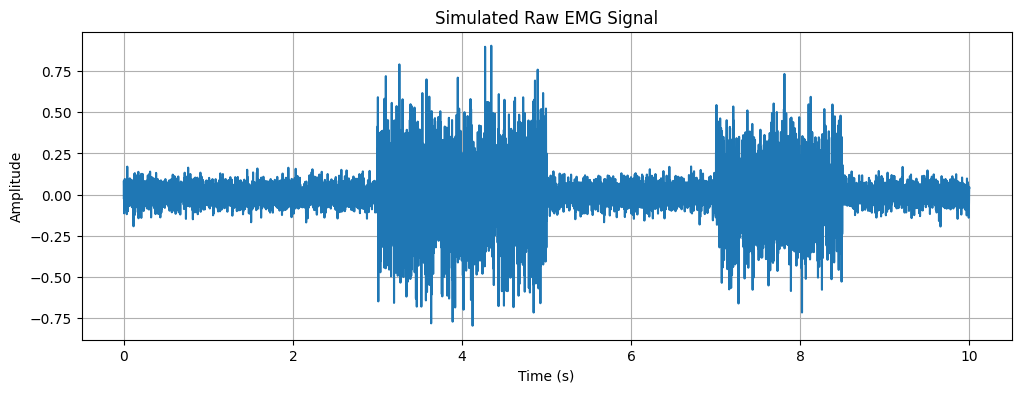

In [4]:
plt.figure(figsize=(12, 4))

plt.plot(t, emg)

plt.title("Simulated Raw EMG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.grid()
plt.show()

In [5]:
rectified = np.abs(emg)

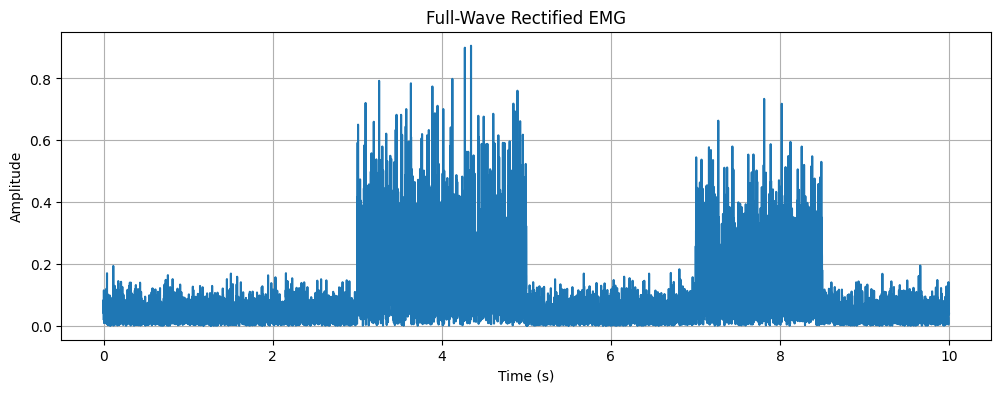

In [6]:
plt.figure(figsize=(12, 4))

plt.plot(t, rectified)

plt.title("Full-Wave Rectified EMG")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.grid()
plt.show()

In [7]:
window = 200

rms = np.sqrt(
    np.convolve(
        emg**2,
        np.ones(window) / window,
        mode='same'
    )
)

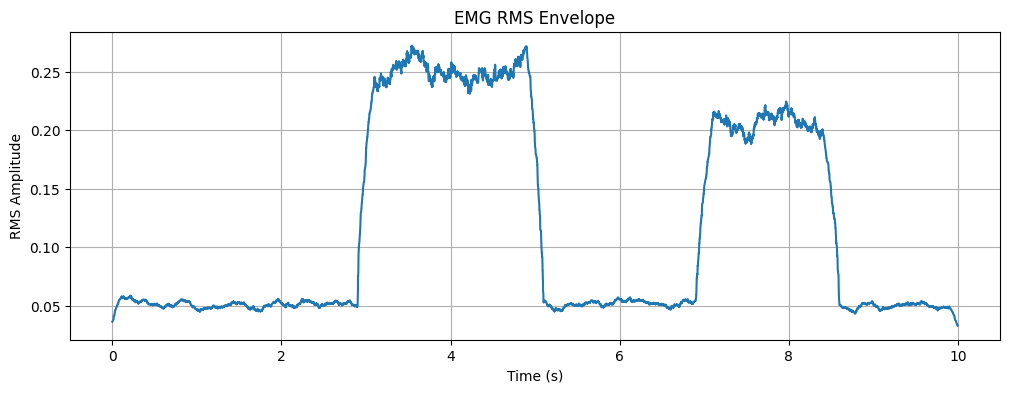

In [8]:
plt.figure(figsize=(12, 4))

plt.plot(t, rms)

plt.title("EMG RMS Envelope")
plt.xlabel("Time (s)")
plt.ylabel("RMS Amplitude")

plt.grid()
plt.show()

In [9]:
threshold = 0.1

activity = rms > threshold

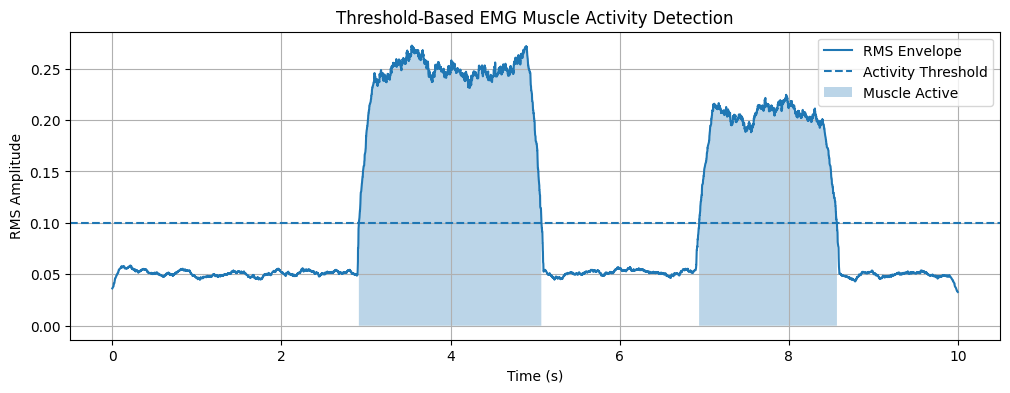

In [10]:
plt.figure(figsize=(12, 4))

plt.plot(t, rms, label="RMS Envelope")
plt.axhline(
    threshold,
    linestyle='--',
    label="Activity Threshold"
)

plt.fill_between(
    t,
    0,
    rms,
    where=activity,
    alpha=0.3,
    label="Muscle Active"
)

plt.xlabel("Time (s)")
plt.ylabel("RMS Amplitude")
plt.title("Threshold-Based EMG Muscle Activity Detection")

plt.legend()
plt.grid()
plt.show()

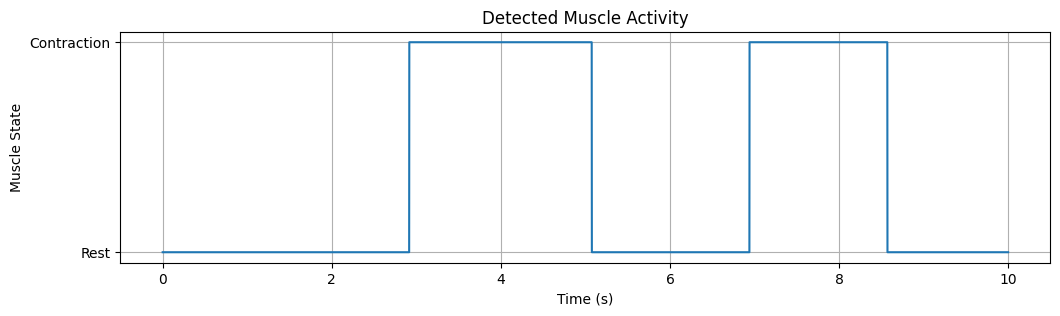

In [11]:
activity_label = np.where(activity, "Contraction", "Rest")

plt.figure(figsize=(12, 3))

plt.plot(t, activity.astype(int))

plt.yticks([0, 1], ["Rest", "Contraction"])
plt.xlabel("Time (s)")
plt.ylabel("Muscle State")
plt.title("Detected Muscle Activity")

plt.grid()
plt.show()

In [12]:
rest_rms = rms[~activity]
contraction_rms = rms[activity]

print("Average RMS during Rest:",
      np.mean(rest_rms))

print("Average RMS during Contraction:",
      np.mean(contraction_rms))

Average RMS during Rest: 0.051175569718457256
Average RMS during Contraction: 0.22134054463419273


In [13]:
import pandas as pd

comparison = pd.DataFrame({
    "Muscle State": ["Rest", "Contraction"],
    "Average RMS": [
        np.mean(rest_rms),
        np.mean(contraction_rms)
    ]
})

comparison

,Muscle State,Average RMS
0,Rest,0.051176
1,Contraction,0.221341


In [14]:
active_duration = np.sum(activity) / fs

print("Detected Muscle Contraction Duration:",
      active_duration, "seconds")

Detected Muscle Contraction Duration: 3.79 seconds


In [ ]:
# ==========================================================
# EMG MUSCLE ACTIVITY DETECTION
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Step 1: Generate simulated EMG
# ----------------------------------------------------------

fs = 1000
duration = 10

t = np.arange(0, duration, 1/fs)

emg = np.random.randn(len(t)) * 0.05

# ----------------------------------------------------------
# Step 2: Simulate muscle contractions
# ----------------------------------------------------------

emg[3000:5000] *= 5
emg[7000:8500] *= 4

# ----------------------------------------------------------
# Step 3: Plot raw EMG
# ----------------------------------------------------------

plt.figure(figsize=(12, 4))
plt.plot(t, emg)

plt.title("Simulated Raw EMG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.grid()
plt.show()

# ----------------------------------------------------------
# Step 4: Full-wave rectification
# ----------------------------------------------------------

rectified = np.abs(emg)

# ----------------------------------------------------------
# Step 5: Plot rectified EMG
# ----------------------------------------------------------

plt.figure(figsize=(12, 4))
plt.plot(t, rectified)

plt.title("Full-Wave Rectified EMG")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.grid()
plt.show()

# ----------------------------------------------------------
# Step 6: Calculate RMS envelope
# ----------------------------------------------------------

window = 200

rms = np.sqrt(
    np.convolve(
        emg**2,
        np.ones(window) / window,
        mode='same'
    )
)

# ----------------------------------------------------------
# Step 7: Plot RMS envelope
# ----------------------------------------------------------

plt.figure(figsize=(12, 4))
plt.plot(t, rms)

plt.title("EMG RMS Envelope")
plt.xlabel("Time (s)")
plt.ylabel("RMS Amplitude")

plt.grid()
plt.show()

# ----------------------------------------------------------
# Step 8: Activity threshold
# ----------------------------------------------------------

threshold = 0.1

activity = rms > threshold

# ----------------------------------------------------------
# Step 9: Threshold-based activity detection
# ----------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.plot(t, rms, label="RMS Envelope")

plt.axhline(
    threshold,
    linestyle='--',
    label="Activity Threshold"
)

plt.fill_between(
    t,
    0,
    rms,
    where=activity,
    alpha=0.3,
    label="Muscle Active"
)

plt.xlabel("Time (s)")
plt.ylabel("RMS Amplitude")
plt.title("Threshold-Based EMG Muscle Activity Detection")

plt.legend()
plt.grid()
plt.show()

# ----------------------------------------------------------
# Step 10: Rest vs Contraction
# ----------------------------------------------------------

rest_rms = rms[~activity]
contraction_rms = rms[activity]

print("Average RMS during Rest:",
      np.mean(rest_rms))

print("Average RMS during Contraction:",
      np.mean(contraction_rms))

# ----------------------------------------------------------
# Step 11: Comparison table
# ----------------------------------------------------------

comparison = pd.DataFrame({
    "Muscle State": ["Rest", "Contraction"],
    "Average RMS": [
        np.mean(rest_rms),
        np.mean(contraction_rms)
    ]
})

print("\nRest vs Contraction Comparison")
display(comparison)

# ----------------------------------------------------------
# Step 12: Detected active duration
# ----------------------------------------------------------

active_duration = np.sum(activity) / fs

print(
    "\nDetected Muscle Contraction Duration:",
    active_duration,
    "seconds"
)

# EMG Muscle Activity Detection Using Python

## Objective

The objective of this experiment is to develop a Python-based EMG signal-processing system to distinguish between muscle relaxation and muscle contraction using full-wave rectification and RMS envelope analysis.

## Methodology

A simulated EMG signal was generated using Python with a sampling frequency of 1000 Hz and a duration of 10 seconds. Two muscle contraction periods were simulated between 3–5 seconds and 7–8.5 seconds by increasing the amplitude of the EMG signal.

The raw EMG signal was first analyzed and plotted. Full-wave rectification was then performed using the absolute value of the signal. An RMS envelope was calculated using a moving window of 200 samples to estimate the level of muscle activity. A threshold of 0.1 was applied to the RMS envelope. Values above the threshold were classified as muscle contraction, while values below the threshold were classified as muscle relaxation.

## Results

The raw EMG signal showed low-amplitude activity during the simulated rest periods and increased-amplitude activity during the contraction periods. After full-wave rectification, the negative signal components were converted into positive values.

The RMS envelope clearly represented the changes in muscle activity. The RMS amplitude increased during the simulated contraction periods and remained relatively low during relaxation.

The threshold-based detection identified the expected sequence:

**Rest → Contraction → Rest → Contraction → Rest**

## Rest vs Contraction

The average RMS value during muscle contraction was higher than the average RMS value during muscle relaxation. This demonstrates that RMS amplitude can be used as an indicator of muscle activation.

| Muscle State | Expected RMS Level |
| ------------ | ------------------ |
| Rest         | Low                |
| Contraction  | High               |

## Conclusion

The Python-based EMG processing system successfully distinguished between simulated muscle relaxation and contraction. Full-wave rectification converted the EMG signal into positive values, while RMS envelope analysis provided a measure of muscle activity. By applying a threshold of 0.1, the system was able to identify the simulated contraction periods. Therefore, RMS-based EMG analysis is an effective method for detecting changes in muscle activity.
